In [3]:
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import replace

from src.config import SimulationConfig
from src.simulator import run_simulation
from src.disorder import generate_breakdown_strength

In [2]:
base_config = SimulationConfig(
    nx=128,
    ny=128,
    eta=1.5,
    correlation_length=5.0,
    random_seed=42,
    disorder_seed=123,
)

weibull_shapes = [2.0, 5.0, 15.0]

results = []

for k in weibull_shapes:
    config = replace(
        base_config,
        weibull_shape=k,
    )

    field, history, breakdown = run_simulation(config)

    strength = generate_breakdown_strength(
        ny=config.ny,
        nx=config.nx,
        correlation_length=config.correlation_length,
        weibull_shape=config.weibull_shape,
        seed=config.disorder_seed,
    )

    results.append(
        (config, field, history, breakdown, strength)
    )

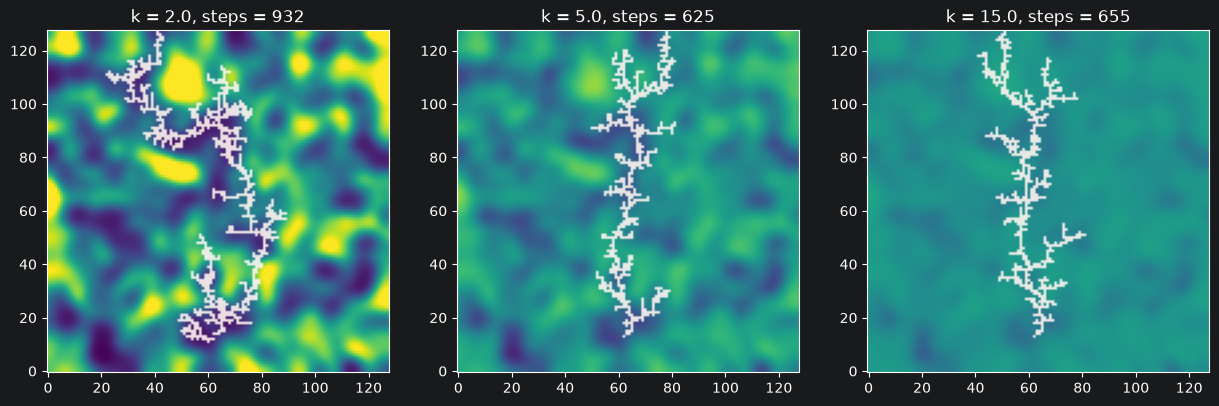

In [3]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
)

for ax, (config, field, history, breakdown, strength) in zip(
    axes,
    results,
):
    ax.imshow(
        strength,
        origin="lower",
        vmin=0.0,
        vmax=2.0,
    )

    channel = np.ma.masked_where(
        ~field.channel,
        field.channel,
    )

    ax.imshow(
        channel,
        origin="lower",
        cmap="Reds",
        alpha=0.9,
    )

    ax.set_title(
        f"k = {config.weibull_shape}, "
        f"steps = {len(history)}"
    )

plt.show()

In [4]:
for config, field, history, breakdown, strength in results:
    mean_material_strength = strength.mean()
    if np.any(field.channel):
        mean_channel_strength = strength[field.channel].mean()
    else:
        mean_channel_strength = np.nan

    print(
        f"k={config.weibull_shape:>4}: "
        f"material={mean_material_strength:.3f}, "
        f"channel={mean_channel_strength:.3f}, "
        f"steps={len(history)}, "
        f"breakdown={breakdown}"
    )

k= 2.0: material=1.000, channel=0.593, steps=932, breakdown=True
k= 5.0: material=1.000, channel=0.873, steps=625, breakdown=True
k=15.0: material=1.000, channel=0.981, steps=655, breakdown=True


In [5]:
from src.config import SimulationConfig
from src.field import ElectricField
from src.disorder import generate_breakdown_strength
from src.growth import get_front

config = SimulationConfig()
field = ElectricField(config)
strength = generate_breakdown_strength(
    ny=config.ny,
    nx=config.nx,
    correlation_length=config.correlation_length,
    weibull_shape=config.weibull_shape,
    seed=config.disorder_seed,
)
field.solve_laplace_sor()
_, _, E = field.electric_field()
conductor = field.needle | field.channel
front = get_front(conductor)
E_front = E[front]
S_front = strength[front]
Ebd_front = (
    config.mean_breakdown_field
    * S_front
)
ratio = E_front / Ebd_front
print("number of front cells:", np.sum(front))
print("E:", E_front)
print("S:", S_front)
print("E_bd:", Ebd_front)
print("E / E_bd:", ratio)
print("active cells:", np.sum(ratio > 1.0))

number of front cells: 29
E: [0.10184455 0.10182992 0.16205548 0.16203246 0.23216761 0.23213483
 0.30859227 0.30854931 0.39171822 0.39166524 0.48339916 0.48333588
 0.5867765  0.58670299 0.70678914 0.70670512 0.85157502 0.8514801
 1.03548995 1.03538364 1.28707915 1.28696158 1.67438004 1.67425028
 2.4130627  2.41292045 2.90683113 2.72606904 2.90675303]
S: [0.93248358 1.06566424 0.91854376 1.05310721 0.8976616  1.0341389
 0.87001692 1.00872883 0.83592217 0.97688149 0.79600883 0.93882147
 0.75126125 0.89498948 0.70302375 0.84616358 0.65314795 0.79362751
 0.6037076  0.73902467 0.55694672 0.6844927  0.5149178  0.63222205
 0.47950198 0.58463083 0.46695478 0.48760443 0.5134316 ]
E_bd: [0.65273851 0.74596497 0.64298063 0.73717505 0.62836312 0.72389723
 0.60901185 0.70611018 0.58514552 0.68381704 0.55720618 0.65717503
 0.52588287 0.62649264 0.49211662 0.59231451 0.45720357 0.55553926
 0.42259532 0.51731727 0.3898627  0.47914489 0.36044246 0.44255544
 0.33565139 0.40924158 0.32686834 0.3413231  0

In [6]:
config = SimulationConfig(
    nx=128,
    ny=128,
    eta=1.5,
    correlation_length=5.0,
    weibull_shape=5.0,
    mean_breakdown_field=0.7,
    random_seed=42,
    disorder_seed=123,
)

field, history, breakdown = run_simulation(config)

print("steps:", len(history))
print("breakdown:", breakdown)

steps: 625
breakdown: True


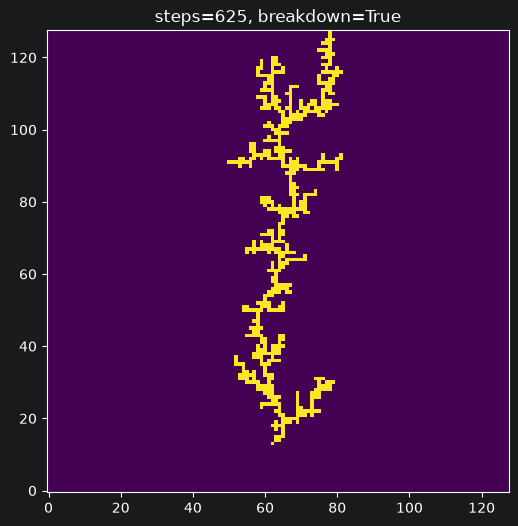

In [7]:
plt.figure(figsize=(6, 6))

plt.imshow(
    field.channel,
    origin="lower",
)

plt.title(
    f"steps={len(history)}, breakdown={breakdown}"
)

plt.show()

In [8]:
thresholds = [
    1.10,
    1.12,
    1.14,
    1.145,
    1.15,
    1.16,
    1.18,
    1.20,
]
results = []

for threshold in thresholds:
    config = SimulationConfig(
        nx=128,
        ny=128,
        eta=1.5,
        correlation_length=5.0,
        weibull_shape=5.0,
        mean_breakdown_field=threshold,
        random_seed=42,
        disorder_seed=123,
    )

    field, history, breakdown = run_simulation(config)

    results.append({
        "threshold": threshold,
        "steps": len(history),
        "breakdown": breakdown,
    })

    print(
        f"E_bd0={threshold:.3f}: "
        f"steps={len(history)}, "
        f"breakdown={breakdown}"
    )



E_bd0=1.100: steps=613, breakdown=True
E_bd0=1.120: steps=559, breakdown=True
E_bd0=1.140: steps=655, breakdown=True
E_bd0=1.145: steps=541, breakdown=True
E_bd0=1.150: steps=616, breakdown=True
E_bd0=1.160: steps=529, breakdown=True
E_bd0=1.180: steps=597, breakdown=True
E_bd0=1.200: steps=613, breakdown=True


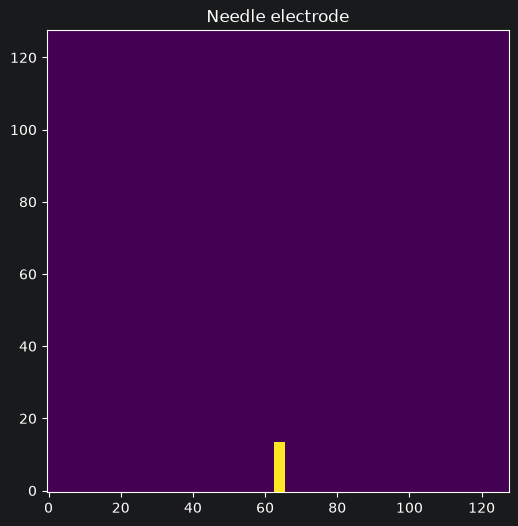

needle cells: 42


In [9]:
config = SimulationConfig()

field = ElectricField(config)

plt.figure(figsize=(6, 6))

plt.imshow(
    field.needle,
    origin="lower",
)

plt.title("Needle electrode")
plt.show()
print("needle cells:", field.needle.sum())

In [10]:
config = SimulationConfig()

field = ElectricField(config)

iterations, residual = field.solve_laplace_sor()

Ex, Ey, E = field.electric_field()

print("iterations:", iterations)
print("residual:", residual)

iterations: 270
residual: 8.647995541455344e-06


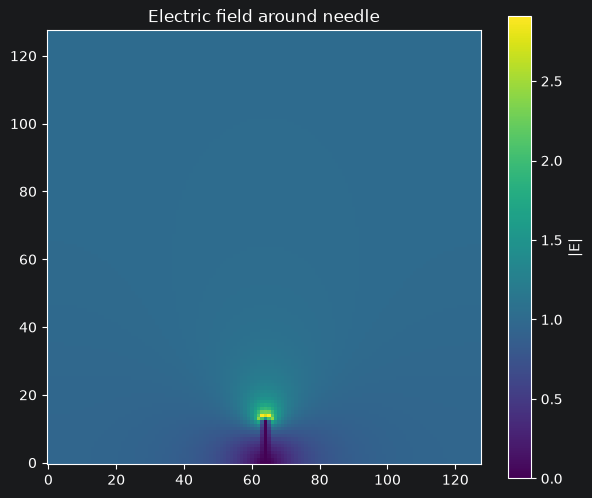

In [11]:
plt.figure(figsize=(7, 6))

plt.imshow(
    E,
    origin="lower",
)

plt.colorbar(label="|E|")
plt.title("Electric field around needle")

plt.show()

In [12]:
dx = config.lx / (config.nx - 1)
dy = config.ly / (config.ny - 1)

needle_length_cells = max(
    1,
    int(round(config.needle_length / dy))
)

tip_x = config.nx // 2
tip_y = needle_length_cells

E_tip = E[tip_y + 1, tip_x]

bulk_x = config.nx // 4
bulk_y = config.ny // 2

E_bulk = E[bulk_y, bulk_x]

enhancement = E_tip / E_bulk

print("tip cell:", (tip_y, tip_x))
print("E_tip =", E_tip)
print("E_bulk =", E_bulk)
print("E_tip / E_bulk =", enhancement)


tip cell: (13, 64)
E_tip = 2.72606903502794
E_bulk = 1.0192641222469776
E_tip / E_bulk = 2.6745462491295138


In [13]:
from src.growth import get_front

conductor = field.needle | field.channel
front = get_front(conductor)

candidates = np.argwhere(front)

E_front = E[front]
S_front = strength[front]

Ebd_front = (
    config.mean_breakdown_field
    * S_front
)

ratio = E_front / Ebd_front

driving = np.maximum(
    ratio - 1.0,
    0.0,
)

weights = driving ** config.eta

if weights.sum() > 0:
    probabilities = weights / weights.sum()
else:
    probabilities = np.zeros_like(weights)

In [14]:
order = np.argsort(probabilities)[::-1]

for idx in order[:10]:
    y, x = candidates[idx]

    print(
        f"(y={y:3d}, x={x:3d})  "
        f"E={E_front[idx]:.3f}  "
        f"S={S_front[idx]:.3f}  "
        f"Ebd={Ebd_front[idx]:.3f}  "
        f"ratio={ratio[idx]:.3f}  "
        f"P={probabilities[idx]:.4f}"
    )

(y= 14, x= 63)  E=2.907  S=0.467  Ebd=0.327  ratio=8.893  P=0.1642
(y= 14, x= 65)  E=2.907  S=0.513  Ebd=0.359  ratio=8.088  P=0.1475
(y= 14, x= 64)  E=2.726  S=0.488  Ebd=0.341  ratio=7.987  P=0.1454
(y= 13, x= 62)  E=2.413  S=0.480  Ebd=0.336  ratio=7.189  P=0.1288
(y= 13, x= 66)  E=2.413  S=0.585  Ebd=0.409  ratio=5.896  P=0.1019
(y= 12, x= 62)  E=1.674  S=0.515  Ebd=0.360  ratio=4.645  P=0.0758
(y= 12, x= 66)  E=1.674  S=0.632  Ebd=0.443  ratio=3.783  P=0.0579
(y= 11, x= 62)  E=1.287  S=0.557  Ebd=0.390  ratio=3.301  P=0.0479
(y= 11, x= 66)  E=1.287  S=0.684  Ebd=0.479  ratio=2.686  P=0.0351
(y= 10, x= 62)  E=1.035  S=0.604  Ebd=0.423  ratio=2.450  P=0.0302


In [15]:
S_homogeneous = np.ones_like(E_front)

Ebd_homogeneous = (
    config.mean_breakdown_field
    * S_homogeneous
)

ratio_homogeneous = (
    E_front / Ebd_homogeneous
)

driving_homogeneous = np.maximum(
    ratio_homogeneous - 1.0,
    0.0,
)

weights_homogeneous = (
    driving_homogeneous ** config.eta
)

probabilities_homogeneous = (
    weights_homogeneous
    / weights_homogeneous.sum()
)

order = np.argsort(
    probabilities_homogeneous
)[::-1]

for idx in order[:10]:
    y, x = candidates[idx]

    print(
        f"(y={y:3d}, x={x:3d})  "
        f"E={E_front[idx]:.3f}  "
        f"ratio={ratio_homogeneous[idx]:.3f}  "
        f"P={probabilities_homogeneous[idx]:.4f}"
    )

(y= 14, x= 63)  E=2.907  ratio=4.153  P=0.1579
(y= 14, x= 65)  E=2.907  ratio=4.153  P=0.1579
(y= 14, x= 64)  E=2.726  ratio=3.894  P=0.1450
(y= 13, x= 62)  E=2.413  ratio=3.447  P=0.1226
(y= 13, x= 66)  E=2.413  ratio=3.447  P=0.1226
(y= 12, x= 62)  E=1.674  ratio=2.392  P=0.0697
(y= 12, x= 66)  E=1.674  ratio=2.392  P=0.0697
(y= 11, x= 62)  E=1.287  ratio=1.839  P=0.0420
(y= 11, x= 66)  E=1.287  ratio=1.839  P=0.0420
(y= 10, x= 62)  E=1.035  ratio=1.479  P=0.0240


In [16]:
config = SimulationConfig(
    nx=128,
    ny=128,
    eta=1.5,
    correlation_length=5.0,
    weibull_shape=5.0,
    mean_breakdown_field=0.7,
    random_seed=42,
    disorder_seed=123,
)

field, history, breakdown = run_simulation(config)

print("steps =", len(history))
print("breakdown =", breakdown)

steps = 625
breakdown = True


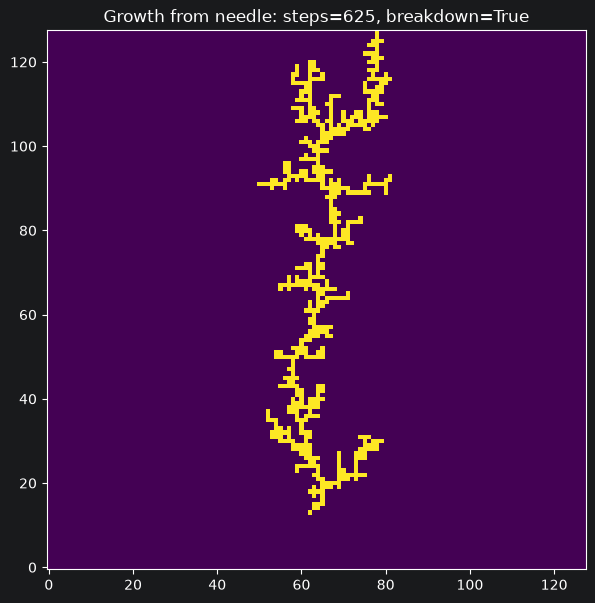

In [17]:
plt.figure(figsize=(7, 7))

plt.imshow(
    field.channel,
    origin="lower",
)

plt.title(
    f"Growth from needle: "
    f"steps={len(history)}, "
    f"breakdown={breakdown}"
)

plt.show()

In [18]:
thresholds = [
    1.0,
    2.0,
    3.0,
    4.0,
    5.0,
    5.5,
    6.0,
    6.2,
    6.3,
]

for threshold in thresholds:
    config = SimulationConfig(
        nx=128,
        ny=128,
        eta=1.5,
        correlation_length=5.0,
        weibull_shape=5.0,
        mean_breakdown_field=threshold,
        random_seed=42,
        disorder_seed=123,
    )

    field, history, breakdown = run_simulation(config)

    if breakdown:
        status = "breakdown"
    elif len(history) == 0:
        status = "no_start"
    else:
        status = "arrested"

    max_y = (
        np.max(np.where(field.channel)[0])
        if np.any(field.channel)
        else None
    )

    print(
        f"E_bd0={threshold:.2f}  "
        f"steps={len(history):4d}  "
        f"max_y={str(max_y):>4}  "
        f"status={status}"
    )

E_bd0=1.00  steps= 631  max_y= 127  status=breakdown
E_bd0=2.00  steps= 503  max_y= 127  status=breakdown
E_bd0=3.00  steps= 360  max_y= 127  status=breakdown
E_bd0=4.00  steps= 307  max_y= 127  status=breakdown
E_bd0=5.00  steps=   0  max_y=None  status=no_start
E_bd0=5.50  steps=   0  max_y=None  status=no_start
E_bd0=6.00  steps=   0  max_y=None  status=no_start
E_bd0=6.20  steps=   0  max_y=None  status=no_start
E_bd0=6.30  steps=   0  max_y=None  status=no_start


In [19]:
config = SimulationConfig(
    nx=128,
    ny=128,
    eta=1.5,
    correlation_length=5.0,
    weibull_shape=5.0,
    random_seed=42,
    disorder_seed=123,
)

field = ElectricField(config)

strength = generate_breakdown_strength(
    ny=config.ny,
    nx=config.nx,
    correlation_length=config.correlation_length,
    weibull_shape=config.weibull_shape,
    seed=config.disorder_seed,
)

field.solve_laplace_sor()
_, _, E = field.electric_field()

conductor = field.needle | field.channel
front = get_front(conductor)

E_front = E[front]
S_front = strength[front]

critical_threshold = np.max(E_front / S_front)

print("critical threshold =", critical_threshold)

for threshold in [4.0, 4.5, 5.0, 5.5, 6.0, 6.3]:
    ratio = E_front / (threshold * S_front)

    print(
        f"E_bd0={threshold:.1f}  "
        f"max_ratio={ratio.max():.3f}  "
        f"active={np.sum(ratio > 1.0)}"
    )

critical threshold = 4.802558431306474
E_bd0=4.0  max_ratio=1.201  active=4
E_bd0=4.5  max_ratio=1.067  active=1
E_bd0=5.0  max_ratio=0.961  active=0
E_bd0=5.5  max_ratio=0.873  active=0
E_bd0=6.0  max_ratio=0.800  active=0
E_bd0=6.3  max_ratio=0.762  active=0


In [21]:
thresholds = [
    4.50,
    4.52,
    4.54,
    4.56,
    4.58,
    4.60,
    4.79,
    4.80,
    4.801,
    4.802,
    4.803,
    4.805,
]

for threshold in thresholds:
    config = SimulationConfig(
        nx=128,
        ny=128,
        eta=1.5,
        correlation_length=5.0,
        weibull_shape=5.0,
        mean_breakdown_field=threshold,
        random_seed=42,
        disorder_seed=123,
    )

    field, history, breakdown = run_simulation(config)

    if breakdown:
        status = "breakdown"
    elif len(history) == 0:
        status = "no_start"
    else:
        status = "arrested"

    max_y = (
        np.max(np.where(field.channel)[0])
        if np.any(field.channel)
        else None
    )

    print(
        f"E_bd0={threshold:.3f}  "
        f"steps={len(history):4d}  "
        f"max_y={str(max_y):>4}  "
        f"status={status}"
    )

E_bd0=4.500  steps= 278  max_y= 127  status=breakdown
E_bd0=4.520  steps= 278  max_y= 127  status=breakdown
E_bd0=4.540  steps= 278  max_y= 127  status=breakdown
E_bd0=4.560  steps= 256  max_y= 127  status=breakdown
E_bd0=4.580  steps=  20  max_y=  27  status=arrested
E_bd0=4.600  steps=  20  max_y=  27  status=arrested
E_bd0=4.790  steps=  17  max_y=  27  status=arrested
E_bd0=4.800  steps=  18  max_y=  26  status=arrested
E_bd0=4.801  steps=  18  max_y=  26  status=arrested
E_bd0=4.802  steps=  18  max_y=  26  status=arrested
E_bd0=4.803  steps=   0  max_y=None  status=no_start
E_bd0=4.805  steps=   0  max_y=None  status=no_start


### Вывод по threshold-режимам

Для фиксированной реализации материала (`disorder_seed = 123`) и фиксированной
стохастической траектории роста (`random_seed = 42`) были обнаружены три различных режима:

$$
\mathrm{breakdown}
\;\longrightarrow\;
\mathrm{arrested}
\;\longrightarrow\;
\mathrm{no\ start}.
$$

При малых значениях базового поля пробоя канал успешно распространяется через весь образец:

$$
E_{\mathrm{bd}}^{(0)} \le 4.560
\qquad\Longrightarrow\qquad
\mathrm{breakdown}.
$$

При увеличении порога появляется промежуточный режим, в котором пробой начинается около
кончика иглы, но останавливается до достижения верхнего электрода:

$$
4.580 \le E_{\mathrm{bd}}^{(0)} \le 4.802
\qquad\Longrightarrow\qquad
\mathrm{arrested}.
$$

При ещё большем пороге ни одна клетка начального фронта не удовлетворяет условию пробоя,
и рост не начинается:

$$
E_{\mathrm{bd}}^{(0)} \ge 4.803
\qquad\Longrightarrow\qquad
\mathrm{no\ start}.
$$

Критический порог старта можно определить независимо от симуляции из локального условия

$$
E_i > E_{\mathrm{bd}}^{(0)} S_i.
$$

Отсюда

$$
E_{\mathrm{bd}}^{(0)}
<
\frac{E_i}{S_i}.
$$

Следовательно, критическое значение базового поля пробоя равно

$$
E_{\mathrm{bd,crit}}^{(0)}
=
\max_{i \in \mathrm{front}}
\left(
\frac{E_i}{S_i}
\right)
\approx 4.80256.
$$

Численный переход между режимами `arrested` и `no start` произошёл между

$$
E_{\mathrm{bd}}^{(0)} = 4.802
$$

и

$$
E_{\mathrm{bd}}^{(0)} = 4.803,
$$

что практически точно совпадает с аналитическим критерием. Это подтверждает корректность
реализации threshold-механизма.

Граница между `breakdown` и `arrested` имеет другой характер. Она зависит не только от
локального электрического поля и структуры материала, но и от стохастической траектории роста.
Поэтому значение около

$$
4.56 < E_{\mathrm{bd}}^{(0)} < 4.58
$$

нельзя считать универсальной критической константой модели.

Следующий шаг — перейти от одной стохастической траектории к ансамблю симуляций и оценить

$$
P_{\mathrm{breakdown}},
\qquad
P_{\mathrm{arrested}},
\qquad
P_{\mathrm{no\ start}}
$$

как функции базового поля пробоя $E_{\mathrm{bd}}^{(0)}$.

In [7]:
import pandas as pd
from tqdm.auto import tqdm

thresholds = [
    4.40,
    4.50,
    4.54,
    4.56,
    4.58,
    4.60,
    4.65,
    4.70,
    4.75,
    4.80,
]

n_seeds = 20
records = []

for threshold in thresholds:

    for random_seed in tqdm(
        range(n_seeds),
        desc=f"E_bd0={threshold:.2f}",
    ):

        config = SimulationConfig(
            nx=128,
            ny=128,
            eta=1.5,
            correlation_length=5.0,
            weibull_shape=5.0,
            mean_breakdown_field=threshold,
            random_seed=random_seed,
            disorder_seed=123,
        )

        field, history, breakdown = run_simulation(config)

        if breakdown:
            status = "breakdown"
        elif len(history) == 0:
            status = "no_start"
        else:
            status = "arrested"

        if np.any(field.channel):
            max_y = int(np.max(np.where(field.channel)[0]))
        else:
            max_y = 0

        records.append({
            "threshold": threshold,
            "random_seed": random_seed,
            "status": status,
            "steps": len(history),
            "max_y": max_y,
        })




E_bd0=4.40:   0%|          | 0/20 [00:00<?, ?it/s]

E_bd0=4.50:   0%|          | 0/20 [00:00<?, ?it/s]

E_bd0=4.54:   0%|          | 0/20 [00:00<?, ?it/s]

E_bd0=4.56:   0%|          | 0/20 [00:00<?, ?it/s]

E_bd0=4.58:   0%|          | 0/20 [00:00<?, ?it/s]

E_bd0=4.60:   0%|          | 0/20 [00:00<?, ?it/s]

E_bd0=4.65:   0%|          | 0/20 [00:00<?, ?it/s]

E_bd0=4.70:   0%|          | 0/20 [00:00<?, ?it/s]

E_bd0=4.75:   0%|          | 0/20 [00:00<?, ?it/s]

E_bd0=4.80:   0%|          | 0/20 [00:00<?, ?it/s]

In [8]:
results_df = pd.DataFrame(records)

results_df

,threshold,random_seed,status,steps,max_y
0,4.4,0,breakdown,248,127
1,4.4,1,breakdown,309,127
2,4.4,2,arrested,22,26
3,4.4,3,arrested,21,28
4,4.4,4,arrested,18,26
...,...,...,...,...,...
195,4.8,15,arrested,18,26
196,4.8,16,arrested,18,27
197,4.8,17,arrested,20,26
198,4.8,18,breakdown,254,127


In [9]:
probabilities_df = (
    results_df
    .groupby(["threshold", "status"])
    .size()
    .unstack(fill_value=0)
    .div(n_seeds)
)

probabilities_df

status,arrested,breakdown
threshold,,
4.40,0.50,0.50
4.50,0.55,0.45
4.54,0.55,0.45
4.56,0.45,0.55
4.58,0.60,0.40
4.60,0.65,0.35
4.65,0.70,0.30
4.70,0.90,0.10
4.75,0.95,0.05


### Вероятностный переход между breakdown и arrested

Для фиксированной реализации материала (`disorder_seed = 123`)
было проведено несколько стохастических реализаций роста
с различными `random_seed`.

Для каждого значения базового поля пробоя оцениваются вероятности

$$
P_{\mathrm{breakdown}}
\left(E_{\mathrm{bd}}^{(0)}\right)
$$

и

$$
P_{\mathrm{arrested}}
\left(E_{\mathrm{bd}}^{(0)}\right).
$$

В отличие от одиночной симуляции, Monte Carlo позволяет рассматривать
переход между режимами как вероятностный, а не как жёсткую границу.

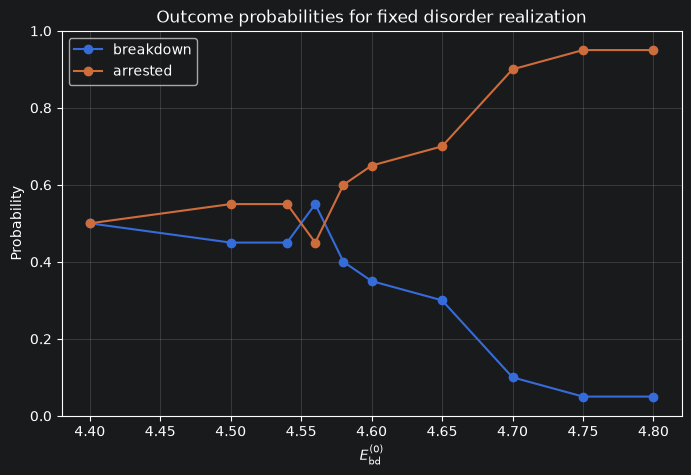

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    probabilities_df.index,
    probabilities_df["breakdown"],
    marker="o",
    label="breakdown",
)

plt.plot(
    probabilities_df.index,
    probabilities_df["arrested"],
    marker="o",
    label="arrested",
)

plt.xlabel(r"$E_{\mathrm{bd}}^{(0)}$")
plt.ylabel("Probability")

plt.ylim(0, 1)

plt.title(
    "Outcome probabilities for fixed disorder realization"
)

plt.grid(alpha=0.3)
plt.legend()

plt.show()